# ATLAS VAE Demo
### Animal Trajectory Latent Alignment Space

This notebook demonstrates the core ATLAS pipeline:
1. **Synthetic data generation** — multidimensional behavioral time series with known latent structure
2. **VAE training** — learning a compressed latent representation
3. **Evaluation** — reconstructions, latent space visualization, and recovery of ground-truth structure

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Synthetic Behavioral Data

We generate **N** trials of behavioral time series with shape `(N, T, D)`.

The data is governed by **K=2 latent factors** — think of these as low-dimensional movement primitives (e.g., speed modulation, limb phase) — linearly mixed into `D=16` observed dimensions, with additive Gaussian noise.

Each trial belongs to one of **3 behavioral conditions** that differ in the mean of the latent trajectory, so a good latent space should cluster by condition.

In [2]:
# ── Data parameters ──────────────────────────────────────────────────────────
N = 600       # number of trials
T = 50        # time steps per trial
D = 16        # observed feature dimensions  (e.g. keypoint coordinates)
K = 2         # true latent dimensions
n_conditions = 3

# Ground-truth condition labels (200 trials each)
labels = np.repeat(np.arange(n_conditions), N // n_conditions)

# Condition-specific latent means  (K-dim)
condition_means = np.array([[2.0, 0.0],
                             [-1.5, 1.5],
                             [-0.5, -2.0]])

# Random linear mixing matrix  (K → D)
W = np.random.randn(D, K) * 0.5

# Generate latent trajectories: slow drift + condition offset
def make_latent_trajectory(mean_k, T):
    """Smooth random-walk trajectory in K-dim latent space."""
    z = np.zeros((T, K))
    z[0] = mean_k + np.random.randn(K) * 0.3
    for t in range(1, T):
        z[t] = 0.95 * z[t-1] + 0.05 * mean_k + np.random.randn(K) * 0.1
    return z  # (T, K)

X_list, Z_true_list = [], []
for n in range(N):
    c = labels[n]
    z = make_latent_trajectory(condition_means[c], T)        # (T, K)
    x = z @ W.T + np.random.randn(T, D) * 0.3               # (T, D)
    X_list.append(x)
    Z_true_list.append(z)

X_np    = np.stack(X_list,     axis=0).astype(np.float32)   # (N, T, D)
Z_np    = np.stack(Z_true_list, axis=0).astype(np.float32)  # (N, T, K)

print(f"Data shape  X : {X_np.shape}   (N, T, D)")
print(f"Latent shape Z: {Z_np.shape}   (N, T, K)")
print(f"Labels       : {np.bincount(labels)}")

Data shape  X : (600, 50, 16)   (N, T, D)
Latent shape Z: (600, 50, 2)   (N, T, K)
Labels       : [200 200 200]


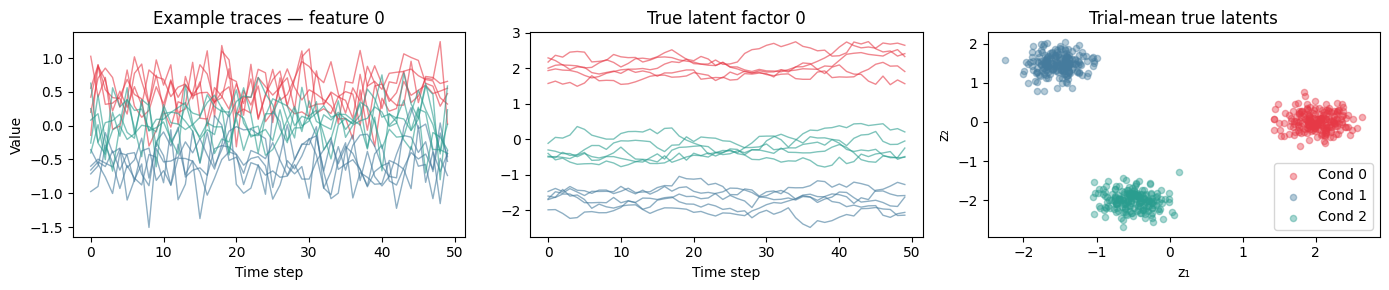

In [3]:
# ── Quick look at the raw data ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
colors = ["#E63946", "#457B9D", "#2A9D8F"]

# Left: a few example time series (first feature dimension)
ax = axes[0]
for c in range(n_conditions):
    idx = np.where(labels == c)[0][:5]
    for i in idx:
        ax.plot(X_np[i, :, 0], color=colors[c], alpha=0.6, lw=1)
ax.set_title("Example traces — feature 0")
ax.set_xlabel("Time step")
ax.set_ylabel("Value")

# Middle: ground-truth latent trajectories (dim 0)
ax = axes[1]
for c in range(n_conditions):
    idx = np.where(labels == c)[0][:5]
    for i in idx:
        ax.plot(Z_np[i, :, 0], color=colors[c], alpha=0.6, lw=1)
ax.set_title("True latent factor 0")
ax.set_xlabel("Time step")

# Right: mean latent trajectory per condition (scatter of trial means)
ax = axes[2]
for c in range(n_conditions):
    idx = labels == c
    ax.scatter(Z_np[idx, :, 0].mean(axis=1),
               Z_np[idx, :, 1].mean(axis=1),
               color=colors[c], alpha=0.4, s=20, label=f"Cond {c}")
ax.set_title("Trial-mean true latents")
ax.set_xlabel("z₁")
ax.set_ylabel("z₂")
ax.legend()

plt.tight_layout()
plt.show()

## 2. ATLAS VAE Architecture

The model processes each trial as a sequence of shape `(T, D)`.

- **Encoder**: a 1-layer GRU reads the sequence and outputs the posterior parameters `(μ, log σ²)` for a latent vector **z** of dimension `latent_dim`.  The latent code is a single vector per trial (trial-level representation).
- **Decoder**: a linear layer projects **z** back to `(T × D)` and reshapes to reconstruct the full sequence.
- **Loss**: ELBO = reconstruction MSE + β · KL divergence from N(0,I).  A β > 1 encourages a more disentangled, regularised latent space.

In [4]:
class ATLASEncoder(nn.Module):
    """GRU encoder: (N, T, D) → μ, log_var  each (N, latent_dim)."""

    def __init__(self, input_dim, hidden_dim, latent_dim, n_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=n_layers,
                          batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x: (N, T, D)
        _, h = self.gru(x)          # h: (n_layers, N, hidden_dim)
        h = h[-1]                   # last-layer hidden: (N, hidden_dim)
        return self.fc_mu(h), self.fc_log_var(h)


class ATLASDecoder(nn.Module):
    """MLP decoder: (N, latent_dim) → (N, T, D)."""

    def __init__(self, latent_dim, hidden_dim, seq_len, output_dim):
        super().__init__()
        self.seq_len    = seq_len
        self.output_dim = output_dim
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, seq_len * output_dim),
        )

    def forward(self, z):
        out = self.net(z)                              # (N, T*D)
        return out.view(-1, self.seq_len, self.output_dim)  # (N, T, D)


class ATLASVAE(nn.Module):
    """Full ATLAS VAE: encodes behavioral sequences into a shared latent space."""

    def __init__(self, input_dim, seq_len, latent_dim=8,
                 hidden_dim=64, n_layers=1, beta=1.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.beta       = beta
        self.encoder    = ATLASEncoder(input_dim, hidden_dim, latent_dim, n_layers)
        self.decoder    = ATLASDecoder(latent_dim, hidden_dim, seq_len, input_dim)

    # ── reparameterisation trick ──────────────────────────────────────────────
    @staticmethod
    def reparameterise(mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    # ── forward pass ──────────────────────────────────────────────────────────
    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparameterise(mu, log_var)
        x_hat       = self.decoder(z)
        return x_hat, mu, log_var

    # ── ELBO loss ─────────────────────────────────────────────────────────────
    def loss(self, x, x_hat, mu, log_var):
        recon = F.mse_loss(x_hat, x, reduction="mean")
        kl    = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
        return recon + self.beta * kl, recon, kl

    # ── convenience wrappers ─────────────────────────────────────────────────
    @torch.no_grad()
    def encode(self, x):
        """Return posterior mean μ for each trial."""
        mu, _ = self.encoder(x)
        return mu

    @torch.no_grad()
    def reconstruct(self, x):
        x_hat, _, _ = self.forward(x)
        return x_hat


# ── Hyperparameters ───────────────────────────────────────────────────────────
latent_dim = 4
hidden_dim = 64
beta       = 2.0      # β-VAE regularisation weight
lr         = 3e-3
n_epochs   = 80
batch_size = 64

model = ATLASVAE(input_dim=D, seq_len=T, latent_dim=latent_dim,
                 hidden_dim=hidden_dim, beta=beta).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ATLAS VAE — {n_params:,} trainable parameters")
print(model)

ATLAS VAE — 68,584 trainable parameters
ATLASVAE(
  (encoder): ATLASEncoder(
    (gru): GRU(16, 64, batch_first=True)
    (fc_mu): Linear(in_features=64, out_features=4, bias=True)
    (fc_log_var): Linear(in_features=64, out_features=4, bias=True)
  )
  (decoder): ATLASDecoder(
    (net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=64, out_features=800, bias=True)
    )
  )
)


## 3. Training

In [5]:
# ── DataLoader ───────────────────────────────────────────────────────────────
X_tensor = torch.from_numpy(X_np).to(device)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ── Optimiser ────────────────────────────────────────────────────────────────
optimiser = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=n_epochs)

# ── Training loop ─────────────────────────────────────────────────────────────
history = {"loss": [], "recon": [], "kl": []}

model.train()
for epoch in range(1, n_epochs + 1):
    ep_loss, ep_recon, ep_kl = 0.0, 0.0, 0.0
    for (xb,) in loader:
        optimiser.zero_grad()
        x_hat, mu, log_var = model(xb)
        loss, recon, kl    = model.loss(xb, x_hat, mu, log_var)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimiser.step()

        ep_loss  += loss.item()
        ep_recon += recon.item()
        ep_kl    += kl.item()

    scheduler.step()
    n_batches = len(loader)
    history["loss"].append(ep_loss / n_batches)
    history["recon"].append(ep_recon / n_batches)
    history["kl"].append(ep_kl / n_batches)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{n_epochs}  "
              f"loss={history['loss'][-1]:.4f}  "
              f"recon={history['recon'][-1]:.4f}  "
              f"kl={history['kl'][-1]:.4f}")

Epoch   1/80  loss=1.1224  recon=1.1092  kl=0.0066


Epoch  10/80  loss=0.9392  recon=0.6614  kl=0.1389


Epoch  20/80  loss=0.9179  recon=0.6374  kl=0.1403


Epoch  30/80  loss=0.9057  recon=0.5834  kl=0.1612


Epoch  40/80  loss=0.8944  recon=0.5690  kl=0.1627


Epoch  50/80  loss=0.8316  recon=0.4824  kl=0.1746


Epoch  60/80  loss=0.8648  recon=0.5074  kl=0.1787


Epoch  70/80  loss=0.8703  recon=0.5206  kl=0.1749


Epoch  80/80  loss=0.8762  recon=0.5304  kl=0.1729


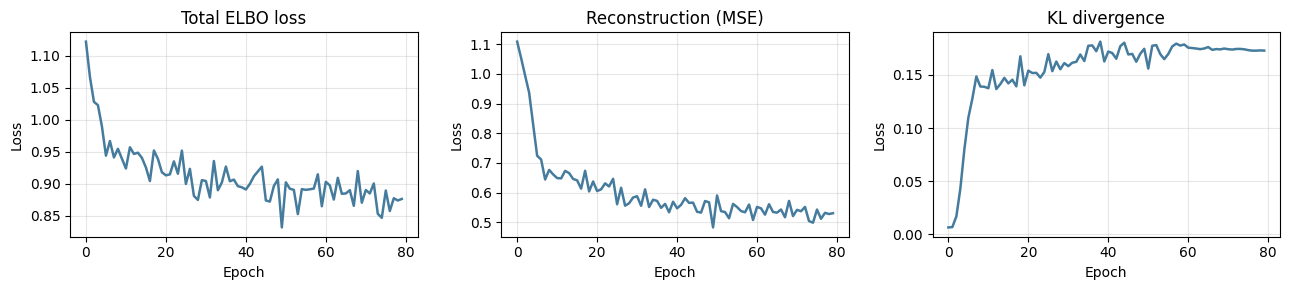

In [6]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, key, title in zip(axes,
                           ["loss", "recon", "kl"],
                           ["Total ELBO loss", "Reconstruction (MSE)", "KL divergence"]):
    ax.plot(history[key], color="#457B9D", lw=1.8)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Evaluation

### 4a. Reconstruction quality

Mean reconstruction MSE: 0.5233 ± 0.4604


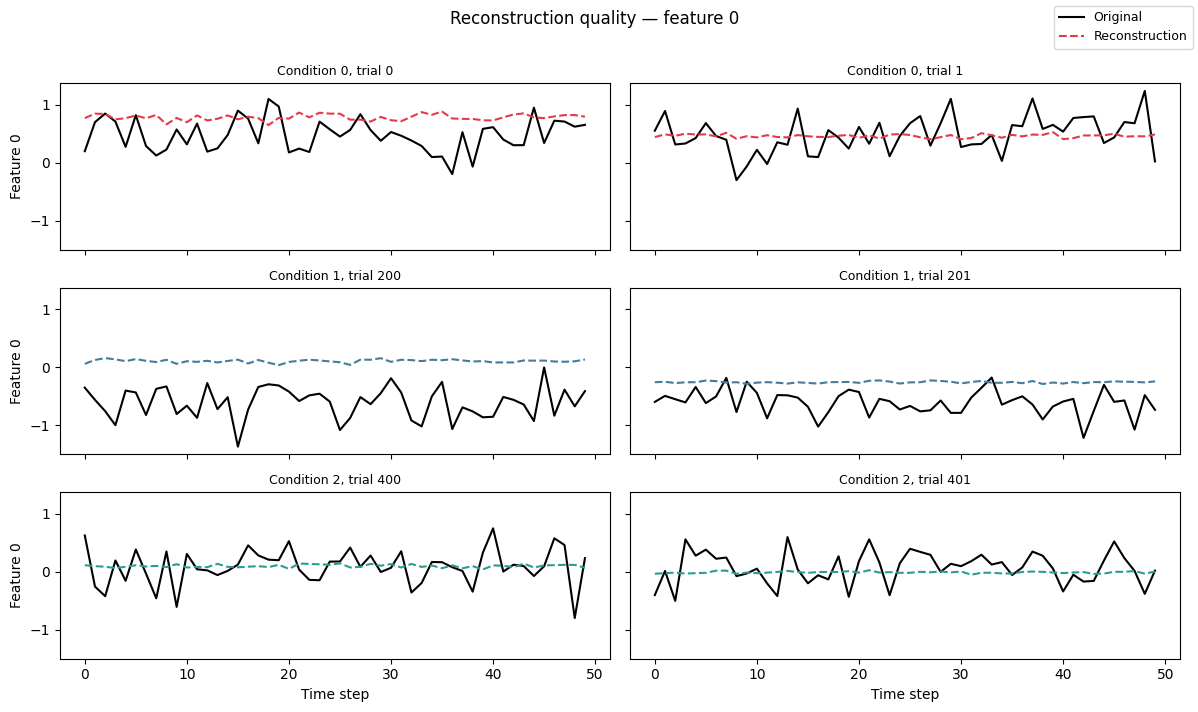

In [7]:
model.eval()
X_hat = model.reconstruct(X_tensor).cpu().numpy()   # (N, T, D)

# Per-trial MSE
mse_per_trial = np.mean((X_np - X_hat) ** 2, axis=(1, 2))
print(f"Mean reconstruction MSE: {mse_per_trial.mean():.4f} ± {mse_per_trial.std():.4f}")

# ── Plot 6 example trials (2 per condition) ───────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True, sharey=True)
for c in range(n_conditions):
    idx = np.where(labels == c)[0]
    for j, trial_i in enumerate(idx[:2]):
        ax = axes[c][j]
        ax.plot(X_np[trial_i, :, 0],  color="black",      lw=1.5, label="Original")
        ax.plot(X_hat[trial_i, :, 0], color=colors[c],    lw=1.5, linestyle="--", label="Reconstruction")
        ax.set_title(f"Condition {c}, trial {trial_i}", fontsize=9)
        if j == 0:
            ax.set_ylabel("Feature 0")
        if c == n_conditions - 1:
            ax.set_xlabel("Time step")

handles, lbls = axes[0][0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="upper right", fontsize=9)
plt.suptitle("Reconstruction quality — feature 0", y=1.01)
plt.tight_layout()
plt.show()

### 4b. Latent space — condition separation

We encode all trials to their posterior mean **μ** and visualise the `latent_dim`-dimensional space via PCA.  A well-trained ATLAS model should cluster the three behavioral conditions without ever seeing the labels during training.

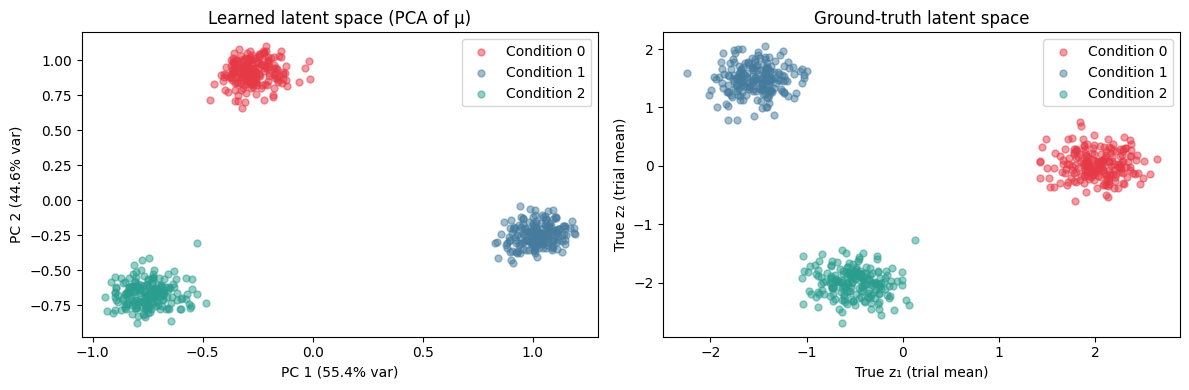

Total PCA variance explained (2 PCs): 100.0%


In [8]:
Z_learned = model.encode(X_tensor).cpu().numpy()   # (N, latent_dim)

# PCA onto 2D for visualisation
pca   = PCA(n_components=2)
Z_2d  = pca.fit_transform(Z_learned)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: learned latent space (PCA) ─────────────────────────────────────────
ax = axes[0]
for c in range(n_conditions):
    idx = labels == c
    ax.scatter(Z_2d[idx, 0], Z_2d[idx, 1],
               color=colors[c], alpha=0.5, s=25, label=f"Condition {c}")
ax.set_xlabel(f"PC 1 ({var_explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC 2 ({var_explained[1]*100:.1f}% var)")
ax.set_title("Learned latent space (PCA of μ)")
ax.legend()

# ── Right: ground-truth latent space (mean over time per trial) ────────────
ax = axes[1]
Z_true_mean = Z_np.mean(axis=1)   # (N, K)
for c in range(n_conditions):
    idx = labels == c
    ax.scatter(Z_true_mean[idx, 0], Z_true_mean[idx, 1],
               color=colors[c], alpha=0.5, s=25, label=f"Condition {c}")
ax.set_xlabel("True z₁ (trial mean)")
ax.set_ylabel("True z₂ (trial mean)")
ax.set_title("Ground-truth latent space")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Total PCA variance explained (2 PCs): {sum(var_explained)*100:.1f}%")

### 4c. Correlation with ground-truth latents

Because the data has known latent structure, we can quantify how well the learned **μ** recovers the true latent factors.  We take the trial-mean of the true latent trajectory and correlate it with each learned latent dimension (after PCA rotation to remove arbitrary axis permutations).

Pearson r — rows: true factors (z₁, z₂)  |  cols: learned PCs (PC1, PC2)
[[-0.515  0.854]
 [ 0.936  0.345]]


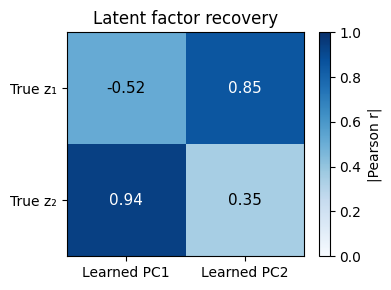

In [9]:
from scipy.stats import pearsonr

# Align ground-truth and learned latents via PCA projections
Z_true_mean = Z_np.mean(axis=1)    # (N, K)  — ground truth (K=2)
Z_learned_2d = Z_2d                # (N, 2)  — learned (PCA-projected)

# Compute all pairwise correlations: each true factor vs each learned PC
corr_matrix = np.zeros((K, 2))
for k in range(K):
    for j in range(2):
        r, p = pearsonr(Z_true_mean[:, k], Z_learned_2d[:, j])
        corr_matrix[k, j] = r

print("Pearson r — rows: true factors (z₁, z₂)  |  cols: learned PCs (PC1, PC2)")
print(np.round(corr_matrix, 3))

# ── Visualise as heatmap ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(np.abs(corr_matrix), vmin=0, vmax=1, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="|Pearson r|")
ax.set_xticks([0, 1]);  ax.set_xticklabels(["Learned PC1", "Learned PC2"])
ax.set_yticks([0, 1]);  ax.set_yticklabels(["True z₁", "True z₂"])
ax.set_title("Latent factor recovery")
for k in range(K):
    for j in range(2):
        ax.text(j, k, f"{corr_matrix[k,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix[k,j]) > 0.6 else "black", fontsize=11)
plt.tight_layout()
plt.show()

### 4d. Latent traversal — interpolating between conditions

A key property of a well-structured VAE is smooth interpolation in the latent space.  Here we linearly interpolate between the mean latent codes of two conditions and decode the resulting sequences.

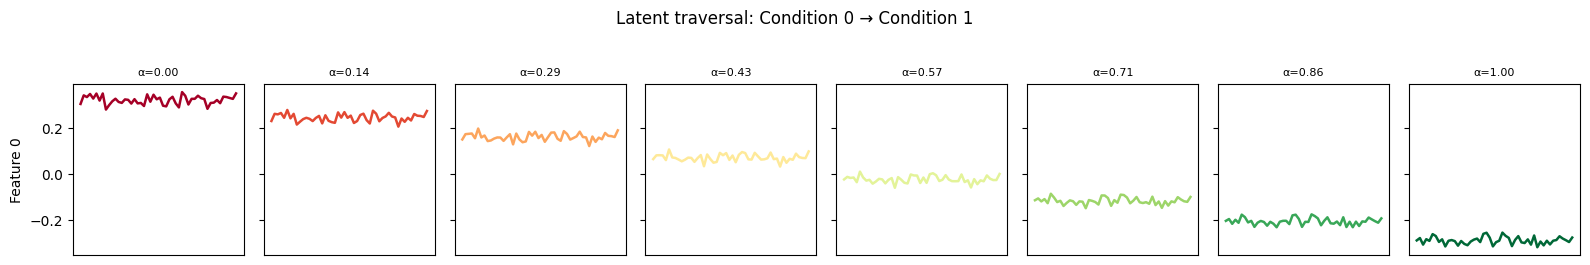

In [10]:
model.eval()

# Condition mean latent codes
Z_learned_tensor = torch.from_numpy(Z_learned).to(device)
cond_means = torch.stack([
    Z_learned_tensor[labels == c].mean(dim=0) for c in range(n_conditions)
])  # (n_conditions, latent_dim)

# Interpolate condition 0 → condition 1
n_steps  = 8
alphas   = np.linspace(0, 1, n_steps)
z_interp = torch.stack([
    (1 - a) * cond_means[0] + a * cond_means[1] for a in alphas
]).to(device)   # (n_steps, latent_dim)

with torch.no_grad():
    x_interp = model.decoder(z_interp).cpu().numpy()  # (n_steps, T, D)

# Plot the interpolated sequences (feature 0)
fig, axes = plt.subplots(1, n_steps, figsize=(16, 2.5), sharey=True)
cmap = plt.cm.RdYlGn
for i, (ax, alpha) in enumerate(zip(axes, alphas)):
    ax.plot(x_interp[i, :, 0], color=cmap(alpha), lw=1.8)
    ax.set_title(f"α={alpha:.2f}", fontsize=8)
    ax.set_xticks([])
    if i == 0:
        ax.set_ylabel("Feature 0")

plt.suptitle("Latent traversal: Condition 0 → Condition 1", y=1.04)
plt.tight_layout()
plt.show()

## 5. Summary

| Component | Detail |
|---|---|
| Data | 600 trials × 50 time steps × 16 features; 3 behavioral conditions; K=2 true latent factors |
| Encoder | 1-layer GRU → linear heads for μ, log σ² |
| Decoder | Linear → ELU → Linear, output (T × D) reshaped to sequence |
| Latent dim | 4 (>K, but the extra dimensions should collapse under regularisation) |
| Loss | β-ELBO with β=2.0 |
| Training | 80 epochs, Adam + cosine LR schedule |

**What this demo shows:**
- Behavioral time series with known low-dimensional structure can be compressed into a structured latent space.
- The three conditions cluster without supervision.
- The first two PCA dimensions of the learned latents correlate strongly with the true generative factors.
- Smooth latent interpolation yields plausible behavioral trajectories.

**Next steps for real data:**
- Swap the synthetic generator for your keypoint / pose data loader.
- Add a cross-animal alignment objective (contrastive or cycle-consistency loss) to map multiple animals into the same space.
- Increase `latent_dim` and use UMAP for higher-dimensional visualisation.
- Save / load weights with `torch.save` / `torch.load`.